<a href="https://colab.research.google.com/github/faezesarlakifar/AllerTrans/blob/main/modeling/nonlinear-DNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# @markdown import necessaries
from google.colab import drive
from tqdm.notebook import tqdm
import torch
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
import numpy as np
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import precision_recall_fscore_support
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import matthews_corrcoef
from sklearn.metrics import roc_auc_score

In [ ]:
# @markdown mount google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
path = '/content/drive/MyDrive/allergen-detection/embeddings/'

In [ ]:
# @markdown load dataset

esm_path = path+'esm-embeddings-with-id/'
esm_train = pd.read_csv(esm_path+'esm_train.csv', index_col=0)
esm_test = pd.read_csv(esm_path+'esm_test.csv', index_col=0)

protbert_path = path+'protBERT-embeddings-with-id/'
protbert_train = pd.read_csv(protbert_path+'protBERT_train.csv', index_col=0)
protbert_test = pd.read_csv(protbert_path+'protBERT_test.csv', index_col=0)

In [ ]:
esm_train.head()

,0,1,2,3,4,5,6,7,8,9,...,1272,1273,1274,1275,1276,1277,1278,1279,Label,id
0,-0.003870,-0.033864,-0.047640,0.042528,0.008789,-0.115301,0.116311,-0.056773,-0.034452,0.007469,...,0.006811,0.046086,-0.028301,0.006903,0.048489,-0.044930,-0.022138,0.003444,0,N_98814
1,-0.027616,-0.047448,-0.092680,-0.037921,-0.064493,-0.085917,0.032686,-0.104749,0.044072,0.136332,...,-0.005730,-0.007972,-0.110330,0.143354,0.079251,-0.200938,-0.064969,-0.010540,1,P_8856
2,-0.060472,-0.009816,-0.085757,-0.042129,-0.005332,-0.114610,-0.023706,-0.015580,0.004648,0.080403,...,-0.015167,-0.000249,-0.056284,0.046674,0.075886,-0.093865,-0.053575,0.069379,1,P_7716
3,-0.001879,-0.132213,0.030315,0.017521,0.093525,-0.132252,0.067915,0.093191,0.031767,0.070513,...,-0.122606,-0.032942,0.069062,-0.176981,0.018370,-0.074525,0.126718,0.107524,0,N_326869
4,-0.004742,-0.012900,-0.069494,0.027048,-0.110435,-0.009641,0.055032,-0.205043,0.036597,0.031489,...,0.036046,-0.113270,-0.020870,-0.023917,0.021013,-0.146265,-0.051615,0.176472,1,P_8031


In [ ]:
esm_test.head()

,0,1,2,3,4,5,6,7,8,9,...,1272,1273,1274,1275,1276,1277,1278,1279,Label,id
0,-0.013756,-0.056206,-0.010463,0.078954,-0.013414,-0.036181,0.101913,-0.078302,-0.029859,0.155479,...,-0.108262,-0.018523,0.023435,-0.086668,0.084220,-0.138123,0.000659,0.111366,0,N_528450
1,0.138220,-0.015468,-0.014704,-0.045518,-0.017561,0.011617,-0.093774,-0.057526,-0.016540,0.202359,...,-0.109726,0.094971,0.022741,-0.153795,0.289212,-0.096826,-0.012760,-0.088842,0,N_479266
2,0.008007,-0.054583,-0.012078,0.037711,-0.046313,-0.094285,0.004338,-0.064758,-0.096635,0.059523,...,-0.036893,0.058147,-0.039131,0.076175,0.136362,-0.062218,-0.023998,0.022915,1,P_271
3,-0.074227,-0.024113,-0.001488,-0.026625,-0.056001,0.005185,-0.002422,-0.120850,-0.008313,-0.003280,...,-0.065336,0.041332,-0.066702,0.075858,-0.057383,-0.165823,0.100414,0.105647,0,N_217429
4,0.035093,-0.027917,0.017686,0.011974,0.123146,-0.051364,-0.024959,0.176133,-0.043006,-0.027118,...,-0.204552,-0.052534,-0.056887,0.034603,0.107830,-0.013466,0.075048,-0.013248,1,P_7456


In [ ]:
protbert_train.head()

,0,1,2,3,4,5,6,7,8,9,...,1016,1017,1018,1019,1020,1021,1022,1023,Label,id
0,0.02951,-0.038240,0.042880,-0.03029,-0.01486,0.09100,-0.02155,-0.07270,0.08460,-0.00852,...,0.017780,-0.064150,0.036220,-0.07806,-0.014550,-0.009850,0.03534,0.02070,1,P_194
1,0.02860,-0.078300,0.044460,-0.03784,0.01002,0.10065,-0.03247,-0.06560,0.07630,-0.01620,...,0.009390,-0.072000,0.019970,-0.10583,-0.012480,-0.009700,0.04852,0.02205,1,P_6357
2,-0.04730,-0.002228,-0.031100,-0.01897,0.02316,0.01805,0.02126,-0.07916,-0.03537,-0.05865,...,-0.019170,0.001675,0.035900,0.00710,0.021940,-0.014656,0.03111,-0.01790,0,N_341543
3,0.01968,0.079900,0.001131,0.03240,0.02434,-0.07947,-0.01135,-0.12840,-0.03787,0.02830,...,-0.000449,-0.206700,-0.005222,0.01127,0.012085,0.014510,0.04248,-0.02217,0,N_257764
4,0.00896,0.022220,0.062230,0.00716,0.03140,0.03087,-0.04764,-0.00948,0.04837,0.02878,...,-0.037500,-0.075500,-0.021120,0.04892,-0.012870,0.023820,-0.04000,-0.06240,0,N_243343


In [ ]:
protbert_test.head()

,0,1,2,3,4,5,6,7,8,9,...,1016,1017,1018,1019,1020,1021,1022,1023,Label,id
0,-0.01852,0.08295,0.03818,-0.01380,-0.015580,-0.020190,0.04840,-0.03552,-0.000656,-0.060150,...,-0.028060,0.01277,0.047550,-0.03232,-0.02292,0.052200,0.02275,-0.023390,1,P_2249
1,-0.02400,0.00681,0.03004,-0.01816,-0.046100,-0.064500,-0.03568,-0.14220,0.004387,-0.063600,...,-0.007454,-0.04565,0.000140,-0.07220,-0.03534,0.021550,0.07184,0.006330,1,P_8311
2,-0.01677,-0.04846,0.03910,0.00860,-0.052100,-0.074800,-0.00942,-0.06480,-0.004760,-0.021060,...,0.003250,-0.04965,-0.008705,-0.03333,-0.04065,-0.021400,0.04794,0.054840,1,P_9307
3,0.01593,-0.05563,0.02385,-0.04205,-0.000392,-0.002066,-0.01698,-0.18870,0.046720,0.049530,...,0.042270,-0.12450,0.048220,0.06020,0.05258,0.003897,-0.00058,-0.027620,0,N_238995
4,-0.00402,-0.08496,0.06910,0.04944,0.025000,-0.015114,-0.06665,-0.06140,-0.004950,0.002924,...,-0.007980,-0.02780,0.069300,0.03119,-0.00836,-0.053560,0.05910,0.003437,0,N_255457


In [ ]:
# @title Concatenate training DataFrames
train = pd.merge(
    left=esm_train,
    right=protbert_train,
    on='id'
)
train.head()

,0_x,1_x,2_x,3_x,4_x,5_x,6_x,7_x,8_x,9_x,...,1015_y,1016_y,1017_y,1018_y,1019_y,1020_y,1021_y,1022_y,1023_y,Label_y
0,-0.003870,-0.033864,-0.047640,0.042528,0.008789,-0.115301,0.116311,-0.056773,-0.034452,0.007469,...,-0.058780,-0.01512,0.01888,0.02798,0.005867,-0.03363,-0.04044,-0.02450,0.034730,0
1,-0.027616,-0.047448,-0.092680,-0.037921,-0.064493,-0.085917,0.032686,-0.104749,0.044072,0.136332,...,0.034600,0.01502,-0.07150,0.05087,-0.082300,-0.01258,-0.01215,0.02357,0.011284,1
2,-0.060472,-0.009816,-0.085757,-0.042129,-0.005332,-0.114610,-0.023706,-0.015580,0.004648,0.080403,...,-0.010414,0.01288,-0.05704,0.01997,0.014015,-0.02370,0.06256,0.04718,0.013390,1
3,-0.001879,-0.132213,0.030315,0.017521,0.093525,-0.132252,0.067915,0.093191,0.031767,0.070513,...,-0.043850,-0.02454,-0.02739,0.04074,0.035600,-0.04605,-0.02040,0.04890,-0.019760,0
4,-0.004742,-0.012900,-0.069494,0.027048,-0.110435,-0.009641,0.055032,-0.205043,0.036597,0.031489,...,0.000988,-0.00882,-0.02419,0.05435,-0.088200,-0.04056,-0.06082,0.02296,0.020160,1


In [ ]:
train['Label'] = train['Label_x']
train = train.drop(columns=['Label_x', 'Label_y'])
train.head()

,0_x,1_x,2_x,3_x,4_x,5_x,6_x,7_x,8_x,9_x,...,1015_y,1016_y,1017_y,1018_y,1019_y,1020_y,1021_y,1022_y,1023_y,Label
0,-0.003870,-0.033864,-0.047640,0.042528,0.008789,-0.115301,0.116311,-0.056773,-0.034452,0.007469,...,-0.058780,-0.01512,0.01888,0.02798,0.005867,-0.03363,-0.04044,-0.02450,0.034730,0
1,-0.027616,-0.047448,-0.092680,-0.037921,-0.064493,-0.085917,0.032686,-0.104749,0.044072,0.136332,...,0.034600,0.01502,-0.07150,0.05087,-0.082300,-0.01258,-0.01215,0.02357,0.011284,1
2,-0.060472,-0.009816,-0.085757,-0.042129,-0.005332,-0.114610,-0.023706,-0.015580,0.004648,0.080403,...,-0.010414,0.01288,-0.05704,0.01997,0.014015,-0.02370,0.06256,0.04718,0.013390,1
3,-0.001879,-0.132213,0.030315,0.017521,0.093525,-0.132252,0.067915,0.093191,0.031767,0.070513,...,-0.043850,-0.02454,-0.02739,0.04074,0.035600,-0.04605,-0.02040,0.04890,-0.019760,0
4,-0.004742,-0.012900,-0.069494,0.027048,-0.110435,-0.009641,0.055032,-0.205043,0.036597,0.031489,...,0.000988,-0.00882,-0.02419,0.05435,-0.088200,-0.04056,-0.06082,0.02296,0.020160,1


In [ ]:
# @title Concatenate test DataFrames
test = pd.merge(
    left=esm_test,
    right=protbert_test,
    on='id'
)
test.head()

,0_x,1_x,2_x,3_x,4_x,5_x,6_x,7_x,8_x,9_x,...,1015_y,1016_y,1017_y,1018_y,1019_y,1020_y,1021_y,1022_y,1023_y,Label_y
0,-0.013756,-0.056206,-0.010463,0.078954,-0.013414,-0.036181,0.101913,-0.078302,-0.029859,0.155479,...,-0.002998,0.026950,-0.05620,0.06690,0.02548,-0.006428,0.04312,0.06300,0.008500,0
1,0.138220,-0.015468,-0.014704,-0.045518,-0.017561,0.011617,-0.093774,-0.057526,-0.016540,0.202359,...,0.035600,-0.014534,-0.08590,0.03397,0.03726,0.012790,-0.02563,0.09100,0.027910,0
2,0.008007,-0.054583,-0.012078,0.037711,-0.046313,-0.094285,0.004338,-0.064758,-0.096635,0.059523,...,-0.038570,-0.009390,-0.03925,0.04712,0.03078,0.004520,-0.02391,0.06647,-0.003840,1
3,-0.074227,-0.024113,-0.001488,-0.026625,-0.056001,0.005185,-0.002422,-0.120850,-0.008313,-0.003280,...,-0.049500,-0.029420,-0.08580,-0.02002,0.03270,-0.029040,-0.06335,0.01161,-0.006042,0
4,0.035093,-0.027917,0.017686,0.011974,0.123146,-0.051364,-0.024959,0.176133,-0.043006,-0.027118,...,0.029170,-0.052730,-0.06920,0.03854,0.11456,-0.035220,-0.01343,0.10626,0.055600,1


In [ ]:
test['Label'] = test['Label_x']
test = test.drop(columns=['Label_x', 'Label_y'])
test.head()

,0_x,1_x,2_x,3_x,4_x,5_x,6_x,7_x,8_x,9_x,...,1015_y,1016_y,1017_y,1018_y,1019_y,1020_y,1021_y,1022_y,1023_y,Label
0,-0.013756,-0.056206,-0.010463,0.078954,-0.013414,-0.036181,0.101913,-0.078302,-0.029859,0.155479,...,-0.002998,0.026950,-0.05620,0.06690,0.02548,-0.006428,0.04312,0.06300,0.008500,0
1,0.138220,-0.015468,-0.014704,-0.045518,-0.017561,0.011617,-0.093774,-0.057526,-0.016540,0.202359,...,0.035600,-0.014534,-0.08590,0.03397,0.03726,0.012790,-0.02563,0.09100,0.027910,0
2,0.008007,-0.054583,-0.012078,0.037711,-0.046313,-0.094285,0.004338,-0.064758,-0.096635,0.059523,...,-0.038570,-0.009390,-0.03925,0.04712,0.03078,0.004520,-0.02391,0.06647,-0.003840,1
3,-0.074227,-0.024113,-0.001488,-0.026625,-0.056001,0.005185,-0.002422,-0.120850,-0.008313,-0.003280,...,-0.049500,-0.029420,-0.08580,-0.02002,0.03270,-0.029040,-0.06335,0.01161,-0.006042,0
4,0.035093,-0.027917,0.017686,0.011974,0.123146,-0.051364,-0.024959,0.176133,-0.043006,-0.027118,...,0.029170,-0.052730,-0.06920,0.03854,0.11456,-0.035220,-0.01343,0.10626,0.055600,1


In [ ]:
df_train = train
df_test = test

# Preprocess and Prepare Dataset

In [ ]:
df_train = df_train.drop('id', axis=1)
df_test = df_test.drop('id', axis=1)

In [ ]:
# Convert Label to integer
df_train['Label'] = df_train['Label'].astype(int)
df_test['Label'] = df_test['Label'].astype(int)

# Split data into train and validation sets
X_train = df_train.drop('Label', axis=1)
y_train = df_train['Label']
X_test = df_test.drop('Label', axis=1)
y_test = df_test['Label']


In [ ]:
# Create new feature names
feature_names = ['feat_'+str(i) for i in range(X_train.shape[1])]

# Rename columns
X_train.columns = feature_names
X_test.columns = feature_names

In [ ]:
scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert to PyTorch tensors
X_train_scaled = torch.from_numpy(X_train_scaled).float()
X_test_scaled = torch.from_numpy(X_test_scaled).float()

X_train = X_train_scaled
X_test = X_test_scaled

In [ ]:
# Convert to numpy arrays
y_train = np.array(y_train)
y_test = np.array(y_test)

# Create Tensors from Labels
y_train = torch.from_numpy(y_train).long()
y_test = torch.from_numpy(y_test).long()

In [ ]:
X_train.shape

torch.Size([16120, 2304])

In [ ]:
y_train.shape

torch.Size([16120])

In [ ]:
X_train_cat = X_train
y_train_cat = y_train

X_test_cat = X_test
y_test_cat = y_test

# ProtT5 + DNN

In [ ]:
# @markdown Load Test Dataset
path = '/content/drive/MyDrive/allergen-detection/embeddings/'

protbert_path = path+'protBERT-embeddings-with-id/'
protbert_train = pd.read_csv(protbert_path+'protBERT_train.csv', index_col=0)
protbert_test = pd.read_csv(protbert_path+'protBERT_test.csv', index_col=0)


df_train = protbert_train
df_test = protbert_test

df_train = df_train.drop('id', axis=1)
df_test = df_test.drop('id', axis=1)

# Convert Label to integer
df_train['Label'] = df_train['Label'].astype(int)
df_test['Label'] = df_test['Label'].astype(int)

# Split data into train and validation sets
X_train = df_train.drop('Label', axis=1)
y_train = df_train['Label']
X_test = df_test.drop('Label', axis=1)
y_test = df_test['Label']

# Create new feature names
feature_names = ['feat_'+str(i) for i in range(X_train.shape[1])]

# Rename columns
X_train.columns = feature_names
X_test.columns = feature_names

scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert to PyTorch tensors
X_train_scaled = torch.from_numpy(X_train_scaled).float()
X_test_scaled = torch.from_numpy(X_test_scaled).float()

X_train = X_train_scaled
X_test = X_test_scaled

# Convert to numpy arrays
y_train = np.array(y_train)
y_test = np.array(y_test)

# Create Tensors from Labels
y_train = torch.from_numpy(y_train).long()
y_test = torch.from_numpy(y_test).long()


In [ ]:
# @title Define ProtT5 Data for Plots
X_train_ProtT5 = X_train
X_test_ProtT5 = X_test
y_train_ProtT5 = y_train
y_test_ProtT5 = y_test

## Define Model

In [ ]:
# Model class
class NeuralNet(nn.Module):
    def __init__(self, input_size, hidden_size1, hidden_size2, hidden_size3, num_classes):
        super(NeuralNet, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size1)
        self.dropout = nn.Dropout(0.1)
        self.fc2 = nn.Linear(hidden_size1, hidden_size2)
        self.dropout = nn.Dropout(0.1)
        self.fc3 = nn.Linear(hidden_size2, hidden_size3)
        self.dropout = nn.Dropout(0.1)
        self.fc4 = nn.Linear(hidden_size3, num_classes)


    def forward(self, x):
        out = F.relu(self.fc1(x))
        out = F.relu(self.fc2(out))
        out = F.relu(self.fc3(out))
        out = self.fc4(out)
        return out

In [ ]:
model_protbert = NeuralNet(1024, 200, 100, 50, 2)

## Train Model

In [ ]:
# Input size, hidden layer sizes, output size
model = NeuralNet(1024, 200, 100, 50, 2)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0003)

batch_size = 128
# Train loop
for epoch in range(10):

        # Iterate over batches
    for i in range(0, len(X_train), batch_size):
        batch_X = X_train[i:i+batch_size]
        batch_y = y_train[i:i+batch_size]

        # Forward pass and loss
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)

        # Backward pass
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

# Test predictions
with torch.no_grad():
    outputs = model(X_test)

# Get predictions
_, predicted = torch.max(outputs.data, 1)

# Convert predicted and y_test to NumPy arrays
predicted_np = predicted.cpu().numpy()
y_test_np = y_test.cpu().numpy()

# Calculate accuracy
accuracy = accuracy_score(y_test_np, predicted_np)

# Calculate precision, recall and F1 score
precision, recall, f1, _ = precision_recall_fscore_support(y_test_np, predicted_np, average='weighted')


# Calculate metrics
_, recall_, _, _ = precision_recall_fscore_support(y_test_np, predicted_np, labels=[0,1])

# Recall for negative class (index 0)
neg_recall = recall_[0]

# Recall for positive class (index 1)
pos_recall = recall_[1]

print("Negative class recall:", neg_recall)
print("Positive class recall:", pos_recall)
# Print metrics
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

# Get probability distribution
probs = F.softmax(model(X_test), dim=1)

# Take positive class probability as scores
y_scores = probs[:,1]

roc_auc = roc_auc_score(y_test, y_scores.detach().numpy())
print("ROCAUC:", roc_auc )

mcc = matthews_corrcoef(y_test, predicted)

print("MCC:", mcc)

Epoch 1, Loss: 0.1183
Epoch 2, Loss: 0.0779
Epoch 3, Loss: 0.0678
Epoch 4, Loss: 0.0620
Epoch 5, Loss: 0.0577
Epoch 6, Loss: 0.0546
Epoch 7, Loss: 0.0523
Epoch 8, Loss: 0.0499
Epoch 9, Loss: 0.0480
Epoch 10, Loss: 0.0457
Negative class recall: 0.96575682382134
Positive class recall: 0.9225806451612903
Accuracy: 0.9441687344913151
Precision: 0.944998292477822
Recall: 0.9441687344913151
F1 Score: 0.9441427024435096
ROCAUC: 0.9767409441594987
MCC: 0.8891666399965088


In [ ]:
model17 = model
torch.save(model17.state_dict(), 'model17-protT5.pt')

Epoch 1, Train Loss: 0.6936, Validation Loss: 0.6890
Epoch 2, Train Loss: 0.6814, Validation Loss: 0.6791
Epoch 3, Train Loss: 0.6665, Validation Loss: 0.6644
Epoch 4, Train Loss: 0.6436, Validation Loss: 0.6420
Epoch 5, Train Loss: 0.6096, Validation Loss: 0.6095
Epoch 6, Train Loss: 0.5634, Validation Loss: 0.5676
Epoch 7, Train Loss: 0.5069, Validation Loss: 0.5188
Epoch 8, Train Loss: 0.4461, Validation Loss: 0.4689
Epoch 9, Train Loss: 0.3873, Validation Loss: 0.4228
Epoch 10, Train Loss: 0.3355, Validation Loss: 0.3832
Epoch 11, Train Loss: 0.2922, Validation Loss: 0.3506
Epoch 12, Train Loss: 0.2575, Validation Loss: 0.3249
Epoch 13, Train Loss: 0.2302, Validation Loss: 0.3050
Epoch 14, Train Loss: 0.2088, Validation Loss: 0.2889
Epoch 15, Train Loss: 0.1916, Validation Loss: 0.2762
Epoch 16, Train Loss: 0.1777, Validation Loss: 0.2667
Epoch 17, Train Loss: 0.1672, Validation Loss: 0.2595
Epoch 18, Train Loss: 0.1589, Validation Loss: 0.2539
Epoch 19, Train Loss: 0.1523, Validat

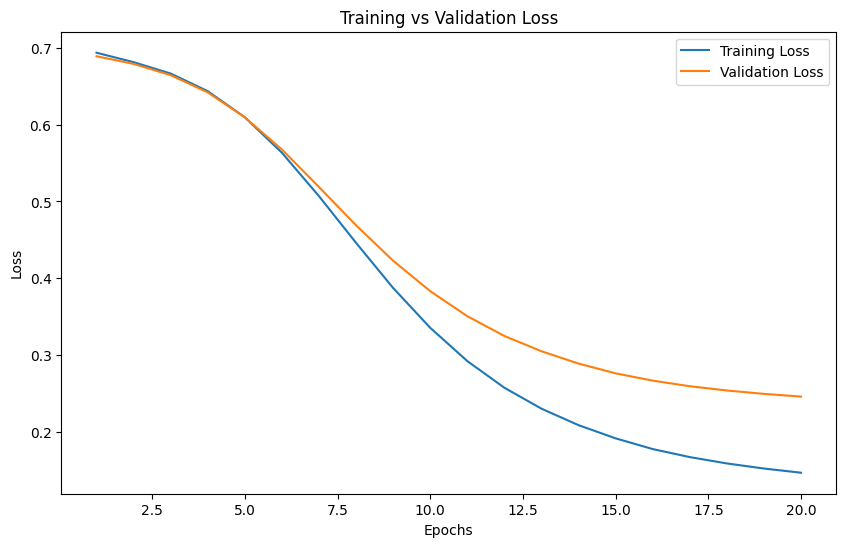

In [ ]:
# @title Learning Curve
import matplotlib.pyplot as plt

# Input size, hidden layer sizes, output size
model = NeuralNet(1024, 200, 100, 50, 2)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.00001)

batch_size = 128

# Lists to store train and validation losses
train_losses = []
val_losses = []

# Train loop
for epoch in range(20):
    model.train()  # Set model to training mode
    epoch_train_loss = 0.0

    # Iterate over batches (training)
    for i in range(0, len(X_train), batch_size):
        batch_X = X_train[i:i+batch_size]
        batch_y = y_train[i:i+batch_size]

        # Forward pass and loss
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)

        # Backward pass
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        # Accumulate loss for the epoch
        epoch_train_loss += loss.item()

    # Average train loss for the epoch
    epoch_train_loss /= (len(X_train) / batch_size)
    train_losses.append(epoch_train_loss)

    # Validation phase using test data (since it's actually validation)
    model.eval()  # Set model to evaluation mode
    with torch.no_grad():
        # Forward pass for validation
        val_outputs = model(X_test)  # Using test data as validation
        val_loss = criterion(val_outputs, y_test)  # Assuming y_test is the validation labels

        # Store validation loss
        val_losses.append(val_loss.item())

    # Print train loss and validation loss
    print(f"Epoch {epoch+1}, Train Loss: {epoch_train_loss:.4f}, Validation Loss: {val_loss.item():.4f}")

# Plot the learning curves (train and validation losses)
plt.figure(figsize=(10, 6))
plt.plot(range(1, 21), train_losses, label='Training Loss')
plt.plot(range(1, 21), val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()


## Cross-validation

In [ ]:
from torch.utils.data import RandomSampler
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import KFold
from torch.utils.data import RandomSampler

In [ ]:
class TensorDataset(torch.utils.data.Dataset):
    def __init__(self, *tensors):
        self.tensors = tensors

    def __getitem__(self, index):
        return tuple(tensor[index] for tensor in self.tensors)

    def __len__(self):
        return self.tensors[0].size(0)

In [ ]:
# Combine training and test data
X = torch.cat((X_train, X_test), dim=0)
y = torch.cat((y_train, y_test), dim=0)

# Create combined dataset
dataset = TensorDataset(X, y)

# Perform KFold cross validation
kfold = KFold(n_splits=5, shuffle=True)

In [ ]:
# Create combined dataset
dataset = TensorDataset(X_train, y_train)

# Perform KFold cross validation
kfold = KFold(n_splits=5, shuffle=True)

In [ ]:
neg_recalls = []
pos_recalls = []
acuracies = []
fScores = []
AUCs = []
MCCs = []
precisions = []

for fold, (train_ids, val_ids) in enumerate(kfold.split(dataset)):

    # Sample elements from train and val ids
  train_sampler = RandomSampler(train_ids)
  val_sampler = RandomSampler(val_ids)

  # Create data loaders
  train_loader = DataLoader(dataset, sampler=train_sampler, batch_size=64)

  len(train_loader)
  val_loader = DataLoader(dataset, sampler=val_sampler, batch_size=64)
  len(val_loader)

  # Input size, hidden layer sizes, output size
  model = NeuralNet(1024, 200, 100, 50, 2)

  # Loss and optimizer
  criterion = nn.CrossEntropyLoss()
  optimizer = torch.optim.Adam(model.parameters(), lr=0.0003)

      # Train model
  epoch = 0
  for x_batch, y_batch in train_loader:
        optimizer.zero_grad()
        y_pred = model(x_batch)
        loss = criterion(y_pred, y_batch)
        loss.backward()
        optimizer.step()

        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}, Fold {fold+1}")
        epoch += 1

  # validate predictions

  X_test_unpacked = []
  y_test_unpacked = []

  for X_test_batch, y_test_batch in val_loader:
    X_test_unpacked.append(X_test_batch)
    y_test_unpacked.append(y_test_batch)

  X_test_unpacked = torch.cat(X_test_unpacked)
  y_test_unpacked = torch.cat(y_test_unpacked)

  X_test = X_test_unpacked
  y_test = y_test_unpacked

  with torch.no_grad():
      outputs = model(X_test)

  # Get predictions
  _, predicted = torch.max(outputs.data, 1)

  # Convert predicted and y_test to NumPy arrays
  predicted_np = predicted.cpu().numpy()
  y_test_np = y_test.cpu().numpy()

  # Calculate accuracy
  accuracy = accuracy_score(y_test_np, predicted_np)

  # Calculate precision, recall and F1 score
  precision, recall, f1, _ = precision_recall_fscore_support(y_test_np, predicted_np, average='weighted')

  # Calculate metrics
  _, recall_, _, _ = precision_recall_fscore_support(y_test_np, predicted_np, labels=[0,1])

  # Recall for negative class (index 0)
  neg_recall = recall_[0]

  # Recall for positive class (index 1)
  pos_recall = recall_[1]

  print("Negative class recall:", neg_recall)
  print("Positive class recall:", pos_recall)
  # Print metrics
  print("Accuracy:", accuracy)
  print("Precision:", precision)
  print("Recall:", recall)
  print("F1 Score:", f1)

  # Get probability distribution
  probs = F.softmax(model(X_test), dim=1)

  # Take positive class probability as scores
  y_scores = probs[:,1]

  roc_auc = roc_auc_score(y_test, y_scores.detach().numpy())
  print("ROCAUC:", roc_auc )

  mcc = matthews_corrcoef(y_test, predicted)

  print("MCC:", mcc)


  neg_recalls.append(neg_recall)
  pos_recalls.append(pos_recall)
  acuracies.append(accuracy)
  fScores.append(f1)
  AUCs.append(roc_auc)
  MCCs.append(mcc)
  precisions.append(precision)


Epoch 1, Loss: 0.6857, Fold 1
Epoch 2, Loss: 0.6872, Fold 1
Epoch 3, Loss: 0.7060, Fold 1
Epoch 4, Loss: 0.6680, Fold 1
Epoch 5, Loss: 0.7021, Fold 1
Epoch 6, Loss: 0.6732, Fold 1
Epoch 7, Loss: 0.7093, Fold 1
Epoch 8, Loss: 0.6758, Fold 1
Epoch 9, Loss: 0.6838, Fold 1
Epoch 10, Loss: 0.6882, Fold 1
Epoch 11, Loss: 0.6875, Fold 1
Epoch 12, Loss: 0.6866, Fold 1
Epoch 13, Loss: 0.6802, Fold 1
Epoch 14, Loss: 0.6783, Fold 1
Epoch 15, Loss: 0.6746, Fold 1
Epoch 16, Loss: 0.6797, Fold 1
Epoch 17, Loss: 0.6737, Fold 1
Epoch 18, Loss: 0.6694, Fold 1
Epoch 19, Loss: 0.6772, Fold 1
Epoch 20, Loss: 0.6708, Fold 1
Epoch 21, Loss: 0.6649, Fold 1
Epoch 22, Loss: 0.6658, Fold 1
Epoch 23, Loss: 0.6584, Fold 1
Epoch 24, Loss: 0.6579, Fold 1
Epoch 25, Loss: 0.6683, Fold 1
Epoch 26, Loss: 0.6741, Fold 1
Epoch 27, Loss: 0.6504, Fold 1
Epoch 28, Loss: 0.6488, Fold 1
Epoch 29, Loss: 0.6475, Fold 1
Epoch 30, Loss: 0.6599, Fold 1
Epoch 31, Loss: 0.6437, Fold 1
Epoch 32, Loss: 0.6440, Fold 1
Epoch 33, Loss: 0

In [ ]:
neg_recalls_avg = np.average(neg_recalls)
pos_recalls_avg = np.average(pos_recalls)
acuracies_avg = np.average(acuracies)
fScores_avg = np.average(fScores)
AUCs_avg = np.average(AUCs)
MCCs_avg = np.average(MCCs)
precisions_avg = np.average(precisions)
print("Negative class recall:", neg_recalls_avg)
print("Positive class recall:", pos_recalls_avg)
  # Print metrics
print("Accuracy:", acuracies_avg)
print("Precision:", precisions_avg)
print("F1 Score:", fScores_avg)
print("ROCAUC:", AUCs_avg)
print("MCC:", MCCs_avg)

Negative class recall: 0.9652985074626865
Positive class recall: 0.9207920792079207
Accuracy: 0.9429900744416873
Precision: 0.9457120236708747
F1 Score: 0.9428988006733379
ROCAUC: 0.9883143071769865
MCC: 0.8887028299711852


## Load Trained Model's Weights

In [ ]:
PATH = '../model-checkpoints/model17-protT5-5.pt'

In [ ]:
model_protT5 = NeuralNet(1024, 200, 100, 50, 2)
model_protT5.load_state_dict(torch.load(PATH))
model_protT5.eval()

<ipython-input-27-d9b053e0c4cc>:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_protT5.load_state_dict(torch.load(PATH))


NeuralNet(
  (fc1): Linear(in_features=1024, out_features=200, bias=True)
  (dropout): Dropout(p=0.1, inplace=False)
  (fc2): Linear(in_features=200, out_features=100, bias=True)
  (fc3): Linear(in_features=100, out_features=50, bias=True)
  (fc4): Linear(in_features=50, out_features=2, bias=True)
)

In [ ]:
model_protbert = model_protT5

# Prot-ESM + DNN

In [ ]:
X_train = X_train_cat
y_train = y_train_cat

X_test = X_test_cat
y_test = y_test_cat

### Define & Train Model

In [ ]:
# Model class
class NeuralNet(nn.Module):
    def __init__(self, input_size, hidden_size1, hidden_size2, hidden_size3, num_classes):
        super(NeuralNet, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size1)
        self.fc2 = nn.Linear(hidden_size1, hidden_size2)
        self.fc3 = nn.Linear(hidden_size2, hidden_size3)
        self.fc4 = nn.Linear(hidden_size3, num_classes)

    def forward(self, x):
        out = F.relu(self.fc1(x))
        out = F.relu(self.fc2(out))
        out = F.relu(self.fc3(out))
        out = F.softmax(self.fc4(out), dim=1)
        return out

In [ ]:
import torch
import torch.nn as nn
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt


# Input size, hidden layer sizes, output size
model = NeuralNet(2304, 200, 100, 100, 2)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

X_val, y_val = X_test, y_test

num_epochs = 150
train_losses = []
val_losses = []
fpr = []
tpr = []

for epoch in range(num_epochs):

  # Train loop
  optimizer.zero_grad()
  outputs = model(X_train)
  loss = criterion(outputs, y_train)
  loss.backward()
  optimizer.step()

  # Validation loop
  with torch.no_grad():
    val_outputs = model(X_val)
    val_loss = criterion(val_outputs, y_val)

  # Store losses
  train_losses.append(loss.item())
  val_losses.append(val_loss.item())

  # Get predictions
  probs = torch.sigmoid(val_outputs)
  preds = (probs > 0.5).float()

  # Calculate ROC curve

  # Get true labels
  y_true = y_val.detach().numpy()

  # Get model outputs
  probs = torch.sigmoid(val_outputs)

  # Print metrics
  print(f"Epoch {epoch+1}: Train Loss - {loss.item():.4f}, Val Loss - {val_loss.item():.4f}")

Epoch 1: Train Loss - 0.6939, Val Loss - 0.6928
Epoch 2: Train Loss - 0.6928, Val Loss - 0.6921
Epoch 3: Train Loss - 0.6919, Val Loss - 0.6915
Epoch 4: Train Loss - 0.6911, Val Loss - 0.6909
Epoch 5: Train Loss - 0.6904, Val Loss - 0.6901
Epoch 6: Train Loss - 0.6896, Val Loss - 0.6895
Epoch 7: Train Loss - 0.6888, Val Loss - 0.6888
Epoch 8: Train Loss - 0.6879, Val Loss - 0.6881
Epoch 9: Train Loss - 0.6871, Val Loss - 0.6874
Epoch 10: Train Loss - 0.6862, Val Loss - 0.6867
Epoch 11: Train Loss - 0.6853, Val Loss - 0.6859
Epoch 12: Train Loss - 0.6844, Val Loss - 0.6850
Epoch 13: Train Loss - 0.6834, Val Loss - 0.6841
Epoch 14: Train Loss - 0.6824, Val Loss - 0.6831
Epoch 15: Train Loss - 0.6813, Val Loss - 0.6823
Epoch 16: Train Loss - 0.6802, Val Loss - 0.6813
Epoch 17: Train Loss - 0.6790, Val Loss - 0.6802
Epoch 18: Train Loss - 0.6777, Val Loss - 0.6791
Epoch 19: Train Loss - 0.6764, Val Loss - 0.6779
Epoch 20: Train Loss - 0.6751, Val Loss - 0.6766
Epoch 21: Train Loss - 0.6737

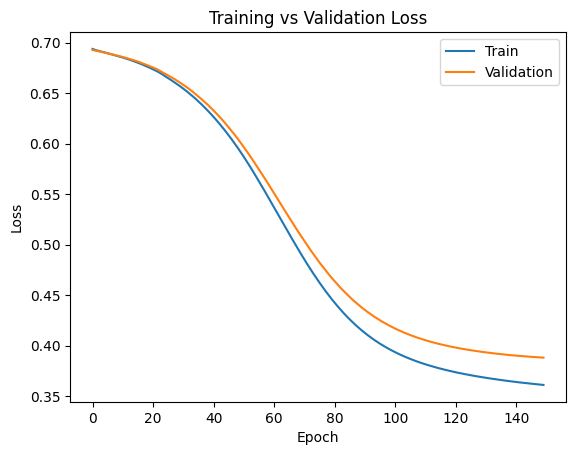

In [ ]:
import matplotlib.pyplot as plt

plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Validation')
plt.legend()
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

In [ ]:
torch.save(model.state_dict(), 'model-prot-esm.pt')

### Load Best Trained Model's Weights

In [ ]:
PATH = '../model-checkpoints/model-esm-protT5-5.pt'

In [ ]:
model_cat = NeuralNet(2304, 200, 100, 100, 2)
model_cat.load_state_dict(torch.load(PATH))
model_cat.eval()

<ipython-input-31-df46eeab4611>:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_cat.load_state_dict(torch.load(PATH))


NeuralNet(
  (fc1): Linear(in_features=2304, out_features=200, bias=True)
  (dropout): Dropout(p=0.1, inplace=False)
  (fc2): Linear(in_features=200, out_features=100, bias=True)
  (fc3): Linear(in_features=100, out_features=100, bias=True)
  (fc4): Linear(in_features=100, out_features=2, bias=True)
)

In [ ]:
# @title Define Prot-ESM model for Plots
model_protESM = model_cat

In [ ]:
concat_test = test

In [ ]:
concat_train = train

In [ ]:
protbert_path = path+'protBERT-embeddings-with-id/'
protbert_train = pd.read_csv(protbert_path+'protBERT_train.csv', index_col=0)
protbert_test = pd.read_csv(protbert_path+'protBERT_test.csv', index_col=0)

protbert_test = protbert_test.set_index('id').reindex(concat_test.id).reset_index()
protbert_train = protbert_train.set_index('id').reindex(concat_train.id).reset_index()

concat_train = concat_train.drop('id', axis=1)
concat_test = concat_test.drop('id', axis=1)
protbert_train = protbert_train.drop('id', axis=1)
protbert_test = protbert_test.drop('id', axis=1)

# Convert Label to integer
concat_train['Label'] = concat_train['Label'].astype(int)
concat_test['Label'] = concat_test['Label'].astype(int)

y_train = concat_train['Label']
y_test = concat_test['Label']

X_train_concat = concat_train.drop('Label', axis=1)
X_test_concat = concat_test.drop('Label', axis=1)

# Convert Label to integer
protbert_train['Label'] = protbert_train['Label'].astype(int)
protbert_test['Label'] = protbert_test['Label'].astype(int)

X_train_protbert = protbert_train.drop('Label', axis=1)
X_test_protbert = protbert_test.drop('Label', axis=1)

scaler = MinMaxScaler()
X_train_concat_scaled = scaler.fit_transform(X_train_concat)
X_test_concat_scaled = scaler.transform(X_test_concat)

# Convert to PyTorch tensors
X_train_concat_scaled = torch.from_numpy(X_train_concat_scaled).float()
X_test_concat_scaled = torch.from_numpy(X_test_concat_scaled).float()

X_train_concat = X_train_concat_scaled
X_test_concat = X_test_concat_scaled

scaler = MinMaxScaler()
X_train_protbert_scaled = scaler.fit_transform(X_train_protbert)
X_test_protbert_scaled = scaler.transform(X_test_protbert)

# Convert to PyTorch tensors
X_train_protbert_scaled = torch.from_numpy(X_train_protbert_scaled).float()
X_test_protbert_scaled = torch.from_numpy(X_test_protbert_scaled).float()

X_train_protbert = X_train_protbert_scaled
X_test_protbert = X_test_protbert_scaled

# Convert to numpy arrays
y_train = np.array(y_train)
y_test = np.array(y_test)

# Create Tensors from Labels
y_train = torch.from_numpy(y_train)
y_test = torch.from_numpy(y_test)

In [ ]:
# @title Define Prot-ESM Data for Plots
X_train_ProtESM = X_train_concat
X_test_ProtESM = X_test_concat
y_train_ProtESM = y_train
y_test_ProtESM = y_test

In [ ]:
# Test predictions
with torch.no_grad():
    outputs = model_cat(X_test_concat)

# Get predictions
_, predicted = torch.max(outputs.data, 1)

# Convert predicted and y_test to NumPy arrays
predicted_np = predicted.cpu().numpy()
y_test_np = y_test.cpu().numpy()

# Calculate accuracy
accuracy = accuracy_score(y_test_np, predicted_np)

# Calculate precision, recall and F1 score
precision, recall, f1, _ = precision_recall_fscore_support(y_test_np, predicted_np, average='weighted')

# Calculate metrics
_, recall_, _, _ = precision_recall_fscore_support(y_test_np, predicted_np, labels=[0,1])

# Recall for negative class (index 0)
neg_recall = recall_[0]

# Recall for positive class (index 1)
pos_recall = recall_[1]

print("Negative class recall:", neg_recall)
print("Positive class recall:", pos_recall)
# Print metrics
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

# Get probability distribution
probs = F.softmax(model_cat(X_test_concat), dim=1)

# Take positive class probability as scores
y_scores = probs[:,1]

roc_auc = roc_auc_score(y_test, y_scores.detach().numpy())
print("ROCAUC:", roc_auc )

mcc = matthews_corrcoef(y_test, predicted)

print("MCC:", mcc)

Negative class recall: 0.9454094292803971
Positive class recall: 0.9325062034739454
Accuracy: 0.9389578163771712
Precision: 0.9390309120545164
Recall: 0.9389578163771712
F1 Score: 0.9389552754937371
ROCAUC: 0.9785447850796446
MCC: 0.8779887253889503


## Cross-validation

In [ ]:
from torch.utils.data import RandomSampler
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import KFold
from torch.utils.data import RandomSampler

In [ ]:
class TensorDataset(torch.utils.data.Dataset):
    def __init__(self, *tensors):
        self.tensors = tensors

    def __getitem__(self, index):
        return tuple(tensor[index] for tensor in self.tensors)

    def __len__(self):
        return self.tensors[0].size(0)

In [ ]:
# Combine training and test data
X = torch.cat((X_train, X_test), dim=0)
y = torch.cat((y_train, y_test), dim=0)

# Create combined dataset
dataset = TensorDataset(X, y)

# Perform KFold cross validation
kfold = KFold(n_splits=5, shuffle=True)

In [ ]:
# Create combined dataset
dataset = TensorDataset(X_train, y_train)

# Perform KFold cross validation
kfold = KFold(n_splits=5, shuffle=True)

In [ ]:
neg_recalls = []
pos_recalls = []
acuracies = []
fScores = []
AUCs = []
MCCs = []
precisions = []

for fold, (train_ids, val_ids) in enumerate(kfold.split(dataset)):

    # Sample elements from train and val ids
  train_sampler = RandomSampler(train_ids)
  val_sampler = RandomSampler(val_ids)

  # Create data loaders
  train_loader = DataLoader(dataset, sampler=train_sampler, batch_size=128)

  len(train_loader)
  val_loader = DataLoader(dataset, sampler=val_sampler, batch_size=128)
  len(val_loader)

  # Input size, hidden layer sizes, output size
  model = NeuralNet(2304, 500, 200, 100, 2)

  # Loss and optimizer
  criterion = nn.CrossEntropyLoss()
  optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)

      # Train model
  epoch = 0
  for x_batch, y_batch in train_loader:
        optimizer.zero_grad()
        y_pred = model(x_batch)
        loss = criterion(y_pred, y_batch)
        loss.backward()
        optimizer.step()

        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}, Fold {fold+1}")
        epoch += 1


  # validate predictions

  X_test_unpacked = []
  y_test_unpacked = []

  for X_test_batch, y_test_batch in val_loader:
    X_test_unpacked.append(X_test_batch)
    y_test_unpacked.append(y_test_batch)

  X_test_unpacked = torch.cat(X_test_unpacked)
  y_test_unpacked = torch.cat(y_test_unpacked)

  X_test = X_test_unpacked
  y_test = y_test_unpacked

  with torch.no_grad():
      outputs = model(X_test)

  # Get predictions
  _, predicted = torch.max(outputs.data, 1)

  # Convert predicted and y_test to NumPy arrays
  predicted_np = predicted.cpu().numpy()
  y_test_np = y_test.cpu().numpy()

  # Calculate accuracy
  accuracy = accuracy_score(y_test_np, predicted_np)

  # Calculate precision, recall and F1 score
  precision, recall, f1, _ = precision_recall_fscore_support(y_test_np, predicted_np, average='weighted')

  # Calculate metrics
  _, recall_, _, _ = precision_recall_fscore_support(y_test_np, predicted_np, labels=[0,1])

  # Recall for negative class (index 0)
  neg_recall = recall_[0]

  # Recall for positive class (index 1)
  pos_recall = recall_[1]

  print("Negative class recall:", neg_recall)
  print("Positive class recall:", pos_recall)
  # Print metrics
  print("Accuracy:", accuracy)
  print("Precision:", precision)
  print("Recall:", recall)
  print("F1 Score:", f1)

  # Get probability distribution
  probs = F.softmax(model(X_test), dim=1)

  # Take positive class probability as scores
  y_scores = probs[:,1]

  roc_auc = roc_auc_score(y_test, y_scores.detach().numpy())
  print("ROCAUC:", roc_auc )

  mcc = matthews_corrcoef(y_test, predicted)

  print("MCC:", mcc)


  neg_recalls.append(neg_recall)
  pos_recalls.append(pos_recall)
  acuracies.append(accuracy)
  fScores.append(f1)
  AUCs.append(roc_auc)
  MCCs.append(mcc)
  precisions.append(precision)


Epoch 1, Loss: 0.7079, Fold 1
Epoch 2, Loss: 0.6932, Fold 1
Epoch 3, Loss: 0.6941, Fold 1
Epoch 4, Loss: 0.6890, Fold 1
Epoch 5, Loss: 0.7103, Fold 1
Epoch 6, Loss: 0.6845, Fold 1
Epoch 7, Loss: 0.6694, Fold 1
Epoch 8, Loss: 0.7548, Fold 1
Epoch 9, Loss: 0.7181, Fold 1
Epoch 10, Loss: 0.6990, Fold 1
Epoch 11, Loss: 0.7010, Fold 1
Epoch 12, Loss: 0.6816, Fold 1
Epoch 13, Loss: 0.6868, Fold 1
Epoch 14, Loss: 0.6811, Fold 1
Epoch 15, Loss: 0.6826, Fold 1
Epoch 16, Loss: 0.6701, Fold 1
Epoch 17, Loss: 0.6666, Fold 1
Epoch 18, Loss: 0.6943, Fold 1
Epoch 19, Loss: 0.6745, Fold 1
Epoch 20, Loss: 0.6658, Fold 1
Epoch 21, Loss: 0.6722, Fold 1
Epoch 22, Loss: 0.6643, Fold 1
Epoch 23, Loss: 0.6500, Fold 1
Epoch 24, Loss: 0.6547, Fold 1
Epoch 25, Loss: 0.6450, Fold 1
Epoch 26, Loss: 0.6382, Fold 1
Epoch 27, Loss: 0.6341, Fold 1
Epoch 28, Loss: 0.6346, Fold 1
Epoch 29, Loss: 0.6300, Fold 1
Epoch 30, Loss: 0.6006, Fold 1
Epoch 31, Loss: 0.5844, Fold 1
Epoch 32, Loss: 0.5913, Fold 1
Epoch 33, Loss: 0

In [ ]:
neg_recalls_avg = np.average(neg_recalls)
pos_recalls_avg = np.average(pos_recalls)
acuracies_avg = np.average(acuracies)
fScores_avg = np.average(fScores)
AUCs_avg = np.average(AUCs)
MCCs_avg = np.average(MCCs)
precisions_avg = np.average(precisions)
print("Negative class recall:", neg_recalls_avg)
print("Positive class recall:", pos_recalls_avg)
  # Print metrics
print("Accuracy:", acuracies_avg)
print("Precision:", precisions_avg)
print("F1 Score:", fScores_avg)
print("ROCAUC:", AUCs_avg)
print("MCC:", MCCs_avg)

Negative class recall: 0.9328301886792453
Positive class recall: 0.9586291309669523
Accuracy: 0.9459057071960298
Precision: 0.9466005984541714
F1 Score: 0.9458729980186942
ROCAUC: 0.9839476378528594
MCC: 0.8924675190722686


# Ensemble models (ProtT5 & Prot-ESM)

In [ ]:
# @markdown Load Train Datasets
path = '/content/drive/MyDrive/allergen-detection/embeddings/'

protbert_path = path+'protBERT-embeddings-with-id/'
protbert_train = pd.read_csv(protbert_path+'protBERT_train.csv', index_col=0)


In [ ]:
# @markdown Load Test Datasets
path = '/content/drive/MyDrive/allergen-detection/embeddings/'

protbert_path = path+'protBERT-embeddings-with-id/'
protbert_test = pd.read_csv(protbert_path+'protBERT_test.csv', index_col=0)


In [ ]:
concat_test = test

In [ ]:
concat_train = train

In [ ]:
# @title Preprocess and prepare dataset
protbert_path = path+'protBERT-embeddings-with-id/'
protbert_train = pd.read_csv(protbert_path+'protBERT_train.csv', index_col=0)
protbert_test = pd.read_csv(protbert_path+'protBERT_test.csv', index_col=0)

protbert_test = protbert_test.set_index('id').reindex(concat_test.id).reset_index()
protbert_train = protbert_train.set_index('id').reindex(concat_train.id).reset_index()

concat_train = concat_train.drop('id', axis=1)
concat_test = concat_test.drop('id', axis=1)
protbert_train = protbert_train.drop('id', axis=1)
protbert_test = protbert_test.drop('id', axis=1)

# Convert Label to integer
concat_train['Label'] = concat_train['Label'].astype(int)
concat_test['Label'] = concat_test['Label'].astype(int)

y_train = concat_train['Label']
y_test = concat_test['Label']

X_train_concat = concat_train.drop('Label', axis=1)
X_test_concat = concat_test.drop('Label', axis=1)

# Convert Label to integer
protbert_train['Label'] = protbert_train['Label'].astype(int)
protbert_test['Label'] = protbert_test['Label'].astype(int)

X_train_protbert = protbert_train.drop('Label', axis=1)
X_test_protbert = protbert_test.drop('Label', axis=1)

scaler = MinMaxScaler()
X_train_concat_scaled = scaler.fit_transform(X_train_concat)
X_test_concat_scaled = scaler.transform(X_test_concat)

# Convert to PyTorch tensors
X_train_concat_scaled = torch.from_numpy(X_train_concat_scaled).float()
X_test_concat_scaled = torch.from_numpy(X_test_concat_scaled).float()

X_train_concat = X_train_concat_scaled
X_test_concat = X_test_concat_scaled

scaler = MinMaxScaler()
X_train_protbert_scaled = scaler.fit_transform(X_train_protbert)
X_test_protbert_scaled = scaler.transform(X_test_protbert)

# Convert to PyTorch tensors
X_train_protbert_scaled = torch.from_numpy(X_train_protbert_scaled).float()
X_test_protbert_scaled = torch.from_numpy(X_test_protbert_scaled).float()

X_train_protbert = X_train_protbert_scaled
X_test_protbert = X_test_protbert_scaled

# Convert to numpy arrays
y_train = np.array(y_train)
y_test = np.array(y_test)

# Create Tensors from Labels
y_train = torch.from_numpy(y_train)
y_test = torch.from_numpy(y_test)

In [ ]:
# Set the weights for each model
weight1 = 0.60
weight2 = 0.30

# Put both models in evaluation mode
model_cat.eval()
model_protbert.eval()

# Iterate over the test dataset and compute the ensemble predictions
with torch.no_grad():
        outputs1 = model_cat(X_test_concat)
        outputs2 = model_protbert(X_test_protbert)
        ensemble_outputs = weight1 * outputs1 + weight2 * outputs2

In [ ]:
_, predicted = torch.max(ensemble_outputs.data, 1)

In [ ]:
ensemble_preds = predicted

In [ ]:
# Convert predicted and y_test to NumPy arrays
ensemble_preds_np = ensemble_preds.cpu().numpy()
y_test_np = y_test.cpu().numpy()

# Calculate accuracy
accuracy = accuracy_score(y_test_np, ensemble_preds_np)

# Calculate precision, recall and F1 score
precision, recall, f1, _ = precision_recall_fscore_support(y_test_np, ensemble_preds_np, average='weighted')

# Calculate metrics
_, recall_, _, _ = precision_recall_fscore_support(y_test_np, ensemble_preds_np, labels=[0,1])

# Recall for negative class (index 0)
neg_recall = recall_[0]

# Recall for positive class (index 1)
pos_recall = recall_[1]

print("Negative class recall:", neg_recall)
print("Positive class recall:", pos_recall)
# Print metrics
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

# Get probability distribution
probs = F.softmax(ensemble_outputs, dim=1)

# Take positive class probability as scores
y_scores = probs[:,1]

roc_auc = roc_auc_score(y_test, y_scores.detach().numpy())
print("ROCAUC:", roc_auc )

mcc = matthews_corrcoef(y_test, predicted)

print("MCC:", mcc)

Negative class recall: 0.9538461538461539
Positive class recall: 0.9349875930521092
Accuracy: 0.9444168734491315
Precision: 0.9445749844596198
Recall: 0.9444168734491315
F1 Score: 0.9444119310400545
ROCAUC: 0.9786590644607133
MCC: 0.8889918438483908


## Five fold on ensembled Prot-ESM + ProtT5

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, SubsetRandomSampler, TensorDataset
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score, matthews_corrcoef

In [ ]:
X1 = X_train_cat
X2 = X_train_protbert
y1 = y2 = y_train

In [ ]:
weights = [0.30, 0.60]

In [ ]:
model1 = model_cat
model2 = model_protbert

In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Lists to store metrics
neg_recalls = []
pos_recalls = []
accuracies = []
fScores = []
AUCs = []
MCCs = []
precisions = []

In [ ]:
def train_and_evaluate(model, train_loader, val_loader, epochs=150, lr=0.003):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        epoch_loss = 0
        model.train()
        for x_batch, y_batch in train_loader:
            optimizer.zero_grad()
            y_pred = model(x_batch)
            loss = criterion(y_pred, y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        print(f"Model 1 - Epoch {epoch+1}, Loss: {epoch_loss/len(train_loader):.4f}")

    model.eval()
    X_test_unpacked, y_test_unpacked = [], []

    for X_test_batch, y_test_batch in val_loader:
        X_test_unpacked.append(X_test_batch)
        y_test_unpacked.append(y_test_batch)

    X_test = torch.cat(X_test_unpacked)
    y_test = torch.cat(y_test_unpacked)

    with torch.no_grad():
        outputs = model(X_test)

    _, predicted = torch.max(outputs.data, 1)

    # Convert predicted and y_test to NumPy arrays
    predicted_np = predicted.cpu().numpy()
    y_test_np = y_test.cpu().numpy()

    # Calculate accuracy
    accuracy = accuracy_score(y_test_np, predicted_np)

    # Calculate precision, recall and F1 score
    precision, recall, f1, _ = precision_recall_fscore_support(y_test_np, predicted_np, average='weighted')

    probs = F.softmax(outputs, dim=1)
    y_scores = probs[:, 1]
    roc_auc = roc_auc_score(y_test, y_scores.detach().numpy())
    mcc = matthews_corrcoef(y_test, predicted)

    _, recall_, _, _ = precision_recall_fscore_support(y_test_np, predicted_np, labels=[0,1])
    neg_recall = recall_[0]
    pos_recall = recall_[1]

    return accuracy, precision, recall, f1, roc_auc, mcc, y_scores, neg_recall, pos_recall

In [ ]:
def train_and_evaluate2(model, X_train, y_train, X_test, y_test, epochs=10, lr=0.0003, batch_size=128):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        model.train()
        for i in range(0, len(X_train), batch_size):
            batch_X = X_train[i:i+batch_size]
            batch_y = y_train[i:i+batch_size]

            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

    model.eval()
    with torch.no_grad():
        outputs = model(X_test)

    _, predicted = torch.max(outputs.data, 1)

    # Convert predicted and y_test to NumPy arrays
    predicted_np = predicted.cpu().numpy()
    y_test_np = y_test.cpu().numpy()

    # Calculate accuracy
    accuracy = accuracy_score(y_test_np, predicted_np)

    # Calculate precision, recall and F1 score
    precision, recall, f1, _ = precision_recall_fscore_support(y_test_np, predicted_np, average='weighted')

    probs = F.softmax(outputs, dim=1)
    y_scores = probs[:, 1]
    roc_auc = roc_auc_score(y_test, y_scores.detach().numpy())
    mcc = matthews_corrcoef(y_test, predicted)

    _, recall_, _, _ = precision_recall_fscore_support(y_test_np, predicted_np, labels=[0,1])
    neg_recall = recall_[0]
    pos_recall = recall_[1]

    return accuracy, precision, recall, f1, roc_auc, mcc, y_scores, neg_recall, pos_recall

### Define Models

#### NeuralNet1

In [ ]:
# Model class
class NeuralNet1(nn.Module):
    def __init__(self, input_size, hidden_size1, hidden_size2, hidden_size3, num_classes):
        super(NeuralNet1, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size1)
        self.dropout = nn.Dropout(0.1)
        self.fc2 = nn.Linear(hidden_size1, hidden_size2)
        self.fc3 = nn.Linear(hidden_size2, hidden_size3)
        self.fc4 = nn.Linear(hidden_size3, num_classes)


    def forward(self, x):
        out = F.relu(self.fc1(x))
        # out = self.dropout(out)
        out = F.relu(self.fc2(out))
        # out = self.dropout(out)
        out = F.relu(self.fc3(out))
        # out = self.dropout(out)
        # Apply softmax
        out = F.softmax(self.fc4(out), dim=1)
        return out

In [ ]:
# Input size, hidden layer sizes, output size
model_cat = NeuralNet1(2304, 200, 100, 100, 2)

#### NeuralNet2

In [ ]:
# Model class
class NeuralNet2(nn.Module):
    def __init__(self, input_size, hidden_size1, hidden_size2, hidden_size3, num_classes):
        super(NeuralNet2, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size1)
        self.dropout = nn.Dropout(0.1)
        self.fc2 = nn.Linear(hidden_size1, hidden_size2)
        self.dropout = nn.Dropout(0.1)
        self.fc3 = nn.Linear(hidden_size2, hidden_size3)
        self.dropout = nn.Dropout(0.1)
        self.fc4 = nn.Linear(hidden_size3, num_classes)


    def forward(self, x):
        out = F.relu(self.fc1(x))
        out = F.relu(self.fc2(out))
        out = F.relu(self.fc3(out))
        out = self.fc4(out)
        return out

In [ ]:
model_protbert = NeuralNet2(1024, 200, 100, 50, 2)

In [ ]:
PATH = '../model-checkpoints/model17-protT5-5.pt'

In [ ]:
model_protbert = NeuralNet(1024, 200, 100, 50, 2)
model_protbert.load_state_dict(torch.load(PATH))
model_protbert.eval()

NeuralNet(
  (fc1): Linear(in_features=1024, out_features=200, bias=True)
  (dropout): Dropout(p=0.1, inplace=False)
  (fc2): Linear(in_features=200, out_features=100, bias=True)
  (fc3): Linear(in_features=100, out_features=50, bias=True)
  (fc4): Linear(in_features=50, out_features=2, bias=True)
)

#### Cross-validation

In [ ]:
for fold, (train_ids, val_ids) in enumerate(kf.split(X1)):
    # Create data loaders for model1 using the same indices
    train_sampler1 = SubsetRandomSampler(train_ids)
    val_sampler1 = SubsetRandomSampler(val_ids)
    train_loader1 = DataLoader(TensorDataset(X1, y1), sampler=train_sampler1, batch_size=64)
    val_loader1 = DataLoader(TensorDataset(X1, y1), sampler=val_sampler1, batch_size=64)

    # Prepare data for model2 using the same indices
    X_train2, y_train2 = X2[train_ids], y2[train_ids]
    X_val2, y_val2 = X2[val_ids], y2[val_ids]

    model1 = NeuralNet1(2304, 500, 200, 100, 2)
    model2 = NeuralNet2(1024, 200, 100, 50, 2)
    # Train and evaluate model1
    acc1, prec1, rec1, f11, roc_auc1, mcc1, y_scores1, neg_recall1, pos_recall1 = train_and_evaluate(model1, train_loader1, val_loader1)

    # Train and evaluate model2
    acc2, prec2, rec2, f12, roc_auc2, mcc2, y_scores2, neg_recall2, pos_recall2 = train_and_evaluate2(model2, X_train2, y_train2, X_val2, y_val2)

    # Combine predictions using the weights
    y_scores_ensemble = (weights[0] * y_scores1 + weights[1] * y_scores2)
    y_pred_ensemble = (y_scores_ensemble > 0.5).int()

    # Convert to NumPy arrays
    y_pred_ensemble_np = y_pred_ensemble.cpu().numpy()
    y1_val_ids_np = y1[val_ids].cpu().numpy()

    # Evaluate the ensemble model
    accuracy = accuracy_score(y1[val_ids], y_pred_ensemble)
    precision, recall, f1, _ = precision_recall_fscore_support(y1[val_ids], y_pred_ensemble, average='weighted')
    roc_auc = roc_auc_score(y1[val_ids], y_scores_ensemble.numpy())
    mcc = matthews_corrcoef(y1[val_ids], y_pred_ensemble)
    _, recall_, _, _ = precision_recall_fscore_support(y1_val_ids_np, y_pred_ensemble_np, labels=[0,1])
    neg_recall = recall_[0]
    pos_recall = recall_[1]

    # Append metrics
    neg_recalls.append(neg_recall)
    pos_recalls.append(pos_recall)
    accuracies.append(accuracy)
    fScores.append(f1)
    AUCs.append(roc_auc)
    MCCs.append(mcc)
    precisions.append(precision)

    print(f"Fold {fold+1} results - Accuracy: {accuracy}, Precision: {precision}, Recall: {recall}, F1 Score: {f1}, ROCAUC: {roc_auc}, MCC: {mcc}")

In [ ]:
# Calculate and print average metrics
print("Average Negative Recall:", np.mean(neg_recalls))
print("Average Positive Recall:", np.mean(pos_recalls))
print("Average Accuracy:", np.mean(accuracies))
print("Average F1 Score:", np.mean(fScores))
print("Average AUC:", np.mean(AUCs))
print("Average MCC:", np.mean(MCCs))
print("Average Precision:", np.mean(precisions))

# ProtAAC results

In [ ]:
path = '/content/drive/MyDrive/allergen-detection/embeddings/'

In [ ]:
# @title load dataset

AAC_path = '/content/drive/MyDrive/allergen-detection/ACC/'
AAC_train = pd.read_csv(AAC_path+'df_train_ACC.csv')
AAC_test = pd.read_csv(AAC_path+'df_valid_ACC.csv')

protbert_path = path+'protBERT-embeddings-with-id/'
protbert_train = pd.read_csv(protbert_path+'protBERT_train.csv', index_col=0)
protbert_test = pd.read_csv(protbert_path+'protBERT_test.csv', index_col=0)

In [ ]:
# @title Concatenate training DataFrames
train = pd.merge(
    left=AAC_train,
    right=protbert_train,
    on='id'
)
train.head()

,AC111,AC112,AC113,AC114,AC115,AC221,AC222,AC223,AC224,AC225,...,1015,1016,1017,1018,1019,1020,1021,1022,1023,Label_y
0,-0.001588,-0.010216,0.009495,0.010611,-0.007591,0.001921,0.004524,0.002681,0.003329,0.003225,...,0.028340,-0.01420,-0.04608,0.01439,0.04850,-0.014435,-0.053040,0.039030,0.03876,1
1,0.002542,-0.000007,-0.003138,0.006212,-0.000897,0.006240,0.000340,0.007036,-0.001322,-0.003758,...,-0.009865,0.01421,-0.13330,-0.02829,0.12120,0.013130,0.092700,0.002281,-0.01819,0
2,0.003587,-0.004062,-0.007729,-0.005593,-0.003180,0.002744,-0.004103,0.004514,-0.000169,0.000349,...,-0.002352,-0.00444,-0.04257,0.04500,-0.08440,-0.033630,-0.055150,0.029940,0.03128,1
3,-0.000019,0.001728,0.004911,-0.003602,-0.001826,-0.000710,-0.000638,-0.005235,0.004258,-0.005560,...,-0.000987,0.02390,-0.08080,0.01773,-0.01240,0.036250,0.014015,0.054900,0.03635,1
4,0.005278,0.001208,0.008769,0.007772,0.001478,-0.005907,0.006403,0.005930,0.007527,0.006052,...,0.016880,0.02052,-0.05603,0.00396,0.01179,-0.034150,-0.037750,-0.054960,-0.00402,0


In [ ]:
train['Label'] = train['Label_x']
train = train.drop(columns=['Label_x', 'Label_y', 'id'])
train.head()

,AC111,AC112,AC113,AC114,AC115,AC221,AC222,AC223,AC224,AC225,...,1015,1016,1017,1018,1019,1020,1021,1022,1023,Label
0,-0.001588,-0.010216,0.009495,0.010611,-0.007591,0.001921,0.004524,0.002681,0.003329,0.003225,...,0.028340,-0.01420,-0.04608,0.01439,0.04850,-0.014435,-0.053040,0.039030,0.03876,1
1,0.002542,-0.000007,-0.003138,0.006212,-0.000897,0.006240,0.000340,0.007036,-0.001322,-0.003758,...,-0.009865,0.01421,-0.13330,-0.02829,0.12120,0.013130,0.092700,0.002281,-0.01819,0
2,0.003587,-0.004062,-0.007729,-0.005593,-0.003180,0.002744,-0.004103,0.004514,-0.000169,0.000349,...,-0.002352,-0.00444,-0.04257,0.04500,-0.08440,-0.033630,-0.055150,0.029940,0.03128,1
3,-0.000019,0.001728,0.004911,-0.003602,-0.001826,-0.000710,-0.000638,-0.005235,0.004258,-0.005560,...,-0.000987,0.02390,-0.08080,0.01773,-0.01240,0.036250,0.014015,0.054900,0.03635,1
4,0.005278,0.001208,0.008769,0.007772,0.001478,-0.005907,0.006403,0.005930,0.007527,0.006052,...,0.016880,0.02052,-0.05603,0.00396,0.01179,-0.034150,-0.037750,-0.054960,-0.00402,0


In [ ]:
# @title Concatenate test DataFrames
test = pd.merge(
    left=AAC_test,
    right=protbert_test,
    on='id'
)
test.head()

,AC111,AC112,AC113,AC114,AC115,AC221,AC222,AC223,AC224,AC225,...,1015,1016,1017,1018,1019,1020,1021,1022,1023,Label_y
0,-0.002709,-0.003017,0.003407,-0.002346,-0.000988,-0.001712,0.000459,-0.000865,0.001448,-0.001776,...,-0.019960,0.000692,-0.04890,0.06192,-0.021940,0.003428,0.03090,0.057830,-0.005928,1
1,-0.001621,-0.003559,0.000425,-0.003073,-0.004361,0.002970,-0.000206,-0.003230,0.001556,-0.000295,...,-0.010345,-0.003754,-0.10200,0.02716,0.036960,-0.006160,-0.05157,-0.005333,0.026460,0
2,0.009525,0.011570,0.006164,0.004729,-0.002226,0.004134,-0.006477,0.004354,0.006389,-0.002751,...,-0.038670,0.029630,-0.08563,0.09766,0.008064,-0.037600,0.02690,0.059500,0.028000,1
3,-0.000123,-0.000442,0.003143,0.002167,0.000882,0.008620,0.003198,0.004305,0.006099,0.006787,...,-0.032600,-0.050960,-0.02983,0.05360,0.001793,-0.046050,0.02757,0.039180,0.024460,0
4,-0.001543,-0.007223,-0.006352,-0.006966,0.002633,0.002969,0.004972,0.003986,0.004642,0.001234,...,-0.046420,-0.038360,-0.05286,0.04060,0.009840,0.000133,0.02797,0.119500,0.075800,1


In [ ]:
test['Label'] = test['Label_x']
test = test.drop(columns=['Label_x', 'Label_y', 'id'])
test.head()

,AC111,AC112,AC113,AC114,AC115,AC221,AC222,AC223,AC224,AC225,...,1015,1016,1017,1018,1019,1020,1021,1022,1023,Label
0,-0.002709,-0.003017,0.003407,-0.002346,-0.000988,-0.001712,0.000459,-0.000865,0.001448,-0.001776,...,-0.019960,0.000692,-0.04890,0.06192,-0.021940,0.003428,0.03090,0.057830,-0.005928,1
1,-0.001621,-0.003559,0.000425,-0.003073,-0.004361,0.002970,-0.000206,-0.003230,0.001556,-0.000295,...,-0.010345,-0.003754,-0.10200,0.02716,0.036960,-0.006160,-0.05157,-0.005333,0.026460,0
2,0.009525,0.011570,0.006164,0.004729,-0.002226,0.004134,-0.006477,0.004354,0.006389,-0.002751,...,-0.038670,0.029630,-0.08563,0.09766,0.008064,-0.037600,0.02690,0.059500,0.028000,1
3,-0.000123,-0.000442,0.003143,0.002167,0.000882,0.008620,0.003198,0.004305,0.006099,0.006787,...,-0.032600,-0.050960,-0.02983,0.05360,0.001793,-0.046050,0.02757,0.039180,0.024460,0
4,-0.001543,-0.007223,-0.006352,-0.006966,0.002633,0.002969,0.004972,0.003986,0.004642,0.001234,...,-0.046420,-0.038360,-0.05286,0.04060,0.009840,0.000133,0.02797,0.119500,0.075800,1


## Preprocess and prepare dataset

In [ ]:
df_train = train
df_test = test

In [ ]:
# Convert Label to integer
df_train['Label'] = df_train['Label'].astype(int)
df_test['Label'] = df_test['Label'].astype(int)

# Split data into train and validation sets
X_train = df_train.drop('Label', axis=1)
y_train = df_train['Label']
X_test = df_test.drop('Label', axis=1)
y_test = df_test['Label']

In [ ]:
# Create new feature names
feature_names = ['feat_'+str(i) for i in range(X_train.shape[1])]

# Rename columns
X_train.columns = feature_names
X_test.columns = feature_names

In [ ]:
scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert to PyTorch tensors
X_train_scaled = torch.from_numpy(X_train_scaled).float()
X_test_scaled = torch.from_numpy(X_test_scaled).float()

X_train = X_train_scaled
X_test = X_test_scaled

In [ ]:
# Convert to numpy arrays
y_train = np.array(y_train)
y_test = np.array(y_test)

# Create Tensors from Labels
y_train = torch.from_numpy(y_train).long()
y_test = torch.from_numpy(y_test).long()

In [ ]:
# @title Define ProtAAC Data for Plots
X_train_ProtAAC = X_train
X_test_ProtAAC = X_test
y_train_ProtAAC = y_train
y_test_ProtAAC = y_test

## Cross Validation

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, SubsetRandomSampler, TensorDataset, RandomSampler
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score, matthews_corrcoef

In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Lists to store metrics
neg_recalls = []
pos_recalls = []
accuracies = []
fScores = []
AUCs = []
MCCs = []
precisions = []

In [ ]:
class TensorDataset(torch.utils.data.Dataset):
    def __init__(self, *tensors):
        self.tensors = tensors

    def __getitem__(self, index):
        return tuple(tensor[index] for tensor in self.tensors)

    def __len__(self):
        return self.tensors[0].size(0)

In [ ]:
# Combine training and test data
X = torch.cat((X_train, X_test), dim=0)
y = torch.cat((y_train, y_test), dim=0)

# Create combined dataset
dataset = TensorDataset(X, y)

# Perform KFold cross validation
kfold = KFold(n_splits=5, shuffle=True)

In [ ]:
neg_recalls = []
pos_recalls = []
acuracies = []
fScores = []
AUCs = []
MCCs = []
precisions = []

for fold, (train_ids, val_ids) in enumerate(kfold.split(dataset)):

    # Sample elements from train and val ids
  train_sampler = RandomSampler(train_ids)
  val_sampler = RandomSampler(val_ids)

  # Create data loaders
  train_loader = DataLoader(dataset, sampler=train_sampler, batch_size=64)

  len(train_loader)
  val_loader = DataLoader(dataset, sampler=val_sampler, batch_size=64)
  len(val_loader)

  # Input size, hidden layer sizes, output size
  model = NeuralNet(1149, 256, 128, 64, 2)

  # Loss and optimizer
  criterion = nn.CrossEntropyLoss()
  optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

      # Train model
  epoch = 0
  for x_batch, y_batch in train_loader:
        optimizer.zero_grad()
        y_pred = model(x_batch)
        loss = criterion(y_pred, y_batch)
        loss.backward()
        optimizer.step()

        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}, Fold {fold+1}")
        epoch += 1

  # validate predictions

  X_test_unpacked = []
  y_test_unpacked = []

  for X_test_batch, y_test_batch in val_loader:
    X_test_unpacked.append(X_test_batch)
    y_test_unpacked.append(y_test_batch)

  X_test_unpacked = torch.cat(X_test_unpacked)
  y_test_unpacked = torch.cat(y_test_unpacked)

  X_test = X_test_unpacked
  y_test = y_test_unpacked

  with torch.no_grad():
      outputs = model(X_test)

  # Get predictions
  _, predicted = torch.max(outputs.data, 1)

  # Calculate accuracy
  accuracy = accuracy_score(y_test, predicted)

  # Calculate precision, recall and F1 score
  precision, recall, f1, _ = precision_recall_fscore_support(y_test, predicted, average='weighted')


  # Convert to NumPy arrays
  y_test_np = y_test.cpu().numpy()
  predicted_np = predicted.cpu().numpy()

  # Calculate metrics
  _, recall_, _, _ = precision_recall_fscore_support(y_test_np, predicted_np, labels=[0,1])

  # Recall for negative class (index 0)
  neg_recall = recall_[0]

  # Recall for positive class (index 1)
  pos_recall = recall_[1]

  print("Negative class recall:", neg_recall)
  print("Positive class recall:", pos_recall)
  # Print metrics
  print("Accuracy:", accuracy)
  print("Precision:", precision)
  print("Recall:", recall)
  print("F1 Score:", f1)

  # Get probability distribution
  probs = F.softmax(model(X_test), dim=1)

  # Take positive class probability as scores
  y_scores = probs[:,1]

  roc_auc = roc_auc_score(y_test, y_scores.detach().numpy())
  print("ROCAUC:", roc_auc )

  mcc = matthews_corrcoef(y_test, predicted)

  print("MCC:", mcc)


  neg_recalls.append(neg_recall)
  pos_recalls.append(pos_recall)
  acuracies.append(accuracy)
  fScores.append(f1)
  AUCs.append(roc_auc)
  MCCs.append(mcc)
  precisions.append(precision)


Epoch 1, Loss: 0.6944, Fold 1
Epoch 2, Loss: 0.6924, Fold 1
Epoch 3, Loss: 0.6889, Fold 1
Epoch 4, Loss: 0.6923, Fold 1
Epoch 5, Loss: 0.7028, Fold 1
Epoch 6, Loss: 0.6945, Fold 1
Epoch 7, Loss: 0.6943, Fold 1
Epoch 8, Loss: 0.6897, Fold 1
Epoch 9, Loss: 0.6887, Fold 1
Epoch 10, Loss: 0.6902, Fold 1
Epoch 11, Loss: 0.6841, Fold 1
Epoch 12, Loss: 0.6859, Fold 1
Epoch 13, Loss: 0.6878, Fold 1
Epoch 14, Loss: 0.6986, Fold 1
Epoch 15, Loss: 0.6979, Fold 1
Epoch 16, Loss: 0.6906, Fold 1
Epoch 17, Loss: 0.6775, Fold 1
Epoch 18, Loss: 0.6768, Fold 1
Epoch 19, Loss: 0.6990, Fold 1
Epoch 20, Loss: 0.6901, Fold 1
Epoch 21, Loss: 0.6860, Fold 1
Epoch 22, Loss: 0.6811, Fold 1
Epoch 23, Loss: 0.6837, Fold 1
Epoch 24, Loss: 0.6797, Fold 1
Epoch 25, Loss: 0.6771, Fold 1
Epoch 26, Loss: 0.6834, Fold 1
Epoch 27, Loss: 0.6814, Fold 1
Epoch 28, Loss: 0.6845, Fold 1
Epoch 29, Loss: 0.6712, Fold 1
Epoch 30, Loss: 0.6767, Fold 1
Epoch 31, Loss: 0.6817, Fold 1
Epoch 32, Loss: 0.6825, Fold 1
Epoch 33, Loss: 0

In [ ]:
neg_recalls_avg = np.average(neg_recalls)
pos_recalls_avg = np.average(pos_recalls)
acuracies_avg = np.average(acuracies)
fScores_avg = np.average(fScores)
AUCs_avg = np.average(AUCs)
MCCs_avg = np.average(MCCs)
precisions_avg = np.average(precisions)
print("Negative class recall:", neg_recalls_avg)
print("Positive class recall:", pos_recalls_avg)
  # Print metrics
print("Accuracy:", acuracies_avg)
print("Precision:", precisions_avg)
print("F1 Score:", fScores_avg)
print("ROCAUC:", AUCs_avg)
print("MCC:", MCCs_avg)

Negative class recall: 0.9284448818897637
Positive class recall: 0.960960960960961
Accuracy: 0.9445657568238213
Precision: 0.946015661561273
F1 Score: 0.944522100747119
ROCAUC: 0.9847424688467996
MCC: 0.8905895230199485


In [ ]:
model_1_protAAC = model

In [ ]:
model_protAAC = model

In [ ]:
torch.save(model_1_protAAC.state_dict(), 'model_1_protAAC.pt')

# Plot ROC Curves

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import torch
import torch.nn.functional as F
import numpy as np

def get_model_predictions(model, X):
    """Get predictions from a single model"""
    model.eval()
    with torch.no_grad():
        outputs = model(X)
        probs = F.softmax(outputs, dim=1)
    return probs

def get_ensemble_predictions(prot_t5_model, prot_esm_model, X1, X2, weights):
    """Get predictions for AllerTrans (ensemble of ProtT5 and ProtESM)"""
    probs1 = get_model_predictions(prot_t5_model, X1)
    probs2 = get_model_predictions(prot_esm_model, X2)
    return weights[0] * probs1 + weights[1] * probs2

def plot_allertrans_comparison(models_config):
    """
    Plot ROC curves for ProtT5+DNN, ProtESM+DNN, ProtAAC+DNN, and AllerTrans ensemble.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 10))

    # Colors for different models
    colors = {
        'protT5': 'blue',
        'prot_esm': 'green',
        'prot_aac': 'red',
        'allertrans': 'purple'
    }

    # Process each individual model
    for model_name, config in models_config.items():
        if model_name != 'ensemble_config':
            model = config['model']
            X_train = config['X_train']
            y_train = config['y_train']
            X_test = config['X_test']
            y_test = config['y_test']

            # Get predictions
            train_probs = get_model_predictions(model, X_train)
            test_probs = get_model_predictions(model, X_test)

            # Convert to numpy
            train_scores = train_probs[:, 1].cpu().numpy()
            test_scores = test_probs[:, 1].cpu().numpy()
            y_train_np = y_train.cpu().numpy() if isinstance(y_train, torch.Tensor) else y_train
            y_test_np = y_test.cpu().numpy() if isinstance(y_test, torch.Tensor) else y_test

            # Calculate ROC curves
            train_fpr, train_tpr, _ = roc_curve(y_train_np, train_scores)
            test_fpr, test_tpr, _ = roc_curve(y_test_np, test_scores)

            train_auc = auc(train_fpr, train_tpr)
            test_auc = auc(test_fpr, test_tpr)

            # Plot curves
            ax1.plot(train_fpr, train_tpr, color=colors[model_name], lw=2,
                    label=f'{config["display_name"]} (AUC = {train_auc:.4f})')
            ax2.plot(test_fpr, test_tpr, color=colors[model_name], lw=2,
                    label=f'{config["display_name"]} (AUC = {test_auc:.4f})')

    # Process AllerTrans ensemble
    if 'ensemble_config' in models_config:
        ens_config = models_config['ensemble_config']
        model1_config = models_config[ens_config['model1_name']]
        model2_config = models_config[ens_config['model2_name']]

        # Get ensemble predictions
        train_probs = get_ensemble_predictions(
            model1_config['model'],
            model2_config['model'],
            model1_config['X_train'],
            model2_config['X_train'],
            ens_config['weights']
        )
        test_probs = get_ensemble_predictions(
            model1_config['model'],
            model2_config['model'],
            model1_config['X_test'],
            model2_config['X_test'],
            ens_config['weights']
        )

        # Calculate ensemble ROC curves
        train_scores = train_probs[:, 1].cpu().numpy()
        test_scores = test_probs[:, 1].cpu().numpy()

        train_fpr, train_tpr, _ = roc_curve(model1_config['y_train'].cpu().numpy(), train_scores)
        test_fpr, test_tpr, _ = roc_curve(model1_config['y_test'].cpu().numpy(), test_scores)

        train_auc = auc(train_fpr, train_tpr)
        test_auc = auc(test_fpr, test_tpr)

        # Plot ensemble curves
        ax1.plot(train_fpr, train_tpr, color=colors['allertrans'], lw=2,
                label=f'AllerTrans (AUC = {train_auc:.4f})')
        ax2.plot(test_fpr, test_tpr, color=colors['allertrans'], lw=2,
                label=f'AllerTrans (AUC = {test_auc:.4f})')

    # Customize plots
    for ax, title in zip([ax1, ax2], ['Training Dataset', 'Validation Dataset']):
        ax.plot([0, 1], [0, 1], 'k--', lw=2)
        ax.set_xlim([0.0, 1.0])
        ax.set_ylim([0.0, 1.02])
        ax.set_xlabel('1 - Specificity')
        ax.set_ylabel('Sensitivity')
        ax.set_title(title)
        ax.legend(loc="lower right")
        ax.grid(True)

    plt.tight_layout()
    return fig

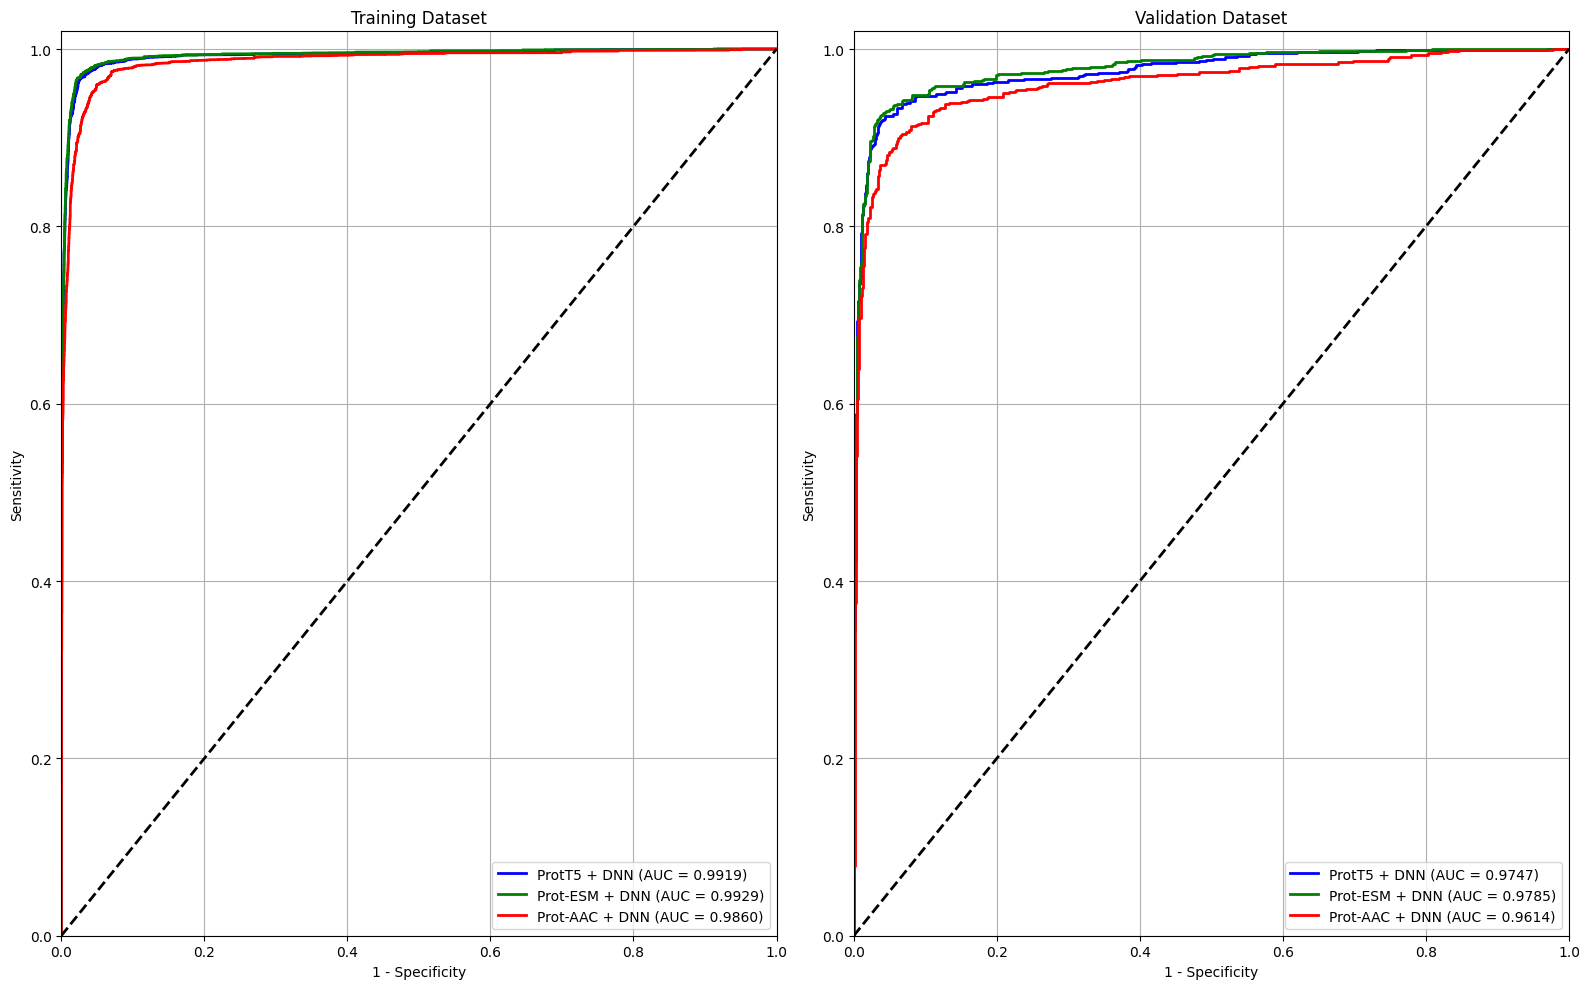

In [ ]:
models_config = {
    'protT5': {
        'model': model_protT5,
        'X_train': X_train_ProtT5,
        'y_train': y_train_ProtT5,
        'X_test': X_test_ProtT5,
        'y_test': y_test_ProtT5,
        'display_name': 'ProtT5 + DNN'
    },
    'prot_esm': {
        'model': model_protESM,
        'X_train': X_train_ProtESM,
        'y_train': y_train_ProtESM,
        'X_test': X_test_ProtESM,
        'y_test': y_test_ProtESM,
        'display_name': 'Prot-ESM + DNN'
    },
    'prot_aac': {
        'model': model_protAAC,
        'X_train': X_train_ProtAAC,
        'y_train': y_train_ProtAAC,
        'X_test': X_test_ProtAAC,
        'y_test': y_test_ProtAAC,
        'display_name': 'Prot-AAC + DNN'
    },
}

# Create the plot
fig = plot_allertrans_comparison(models_config)
plt.show()